<a href="https://colab.research.google.com/github/pmiqueta-oss/ecommerce-delivery-analytics/blob/main/analise_dados_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- INICIANDO PROCESSAMENTO DE DADOS COM PANDAS ---")

# 1. Criando uma base de dados simulada de vendas e entregas
dados_vendas = {
    "ID_Pedido": [101, 102, 103, 104, 105, 106, 107, 108],
    "Cliente": ["Ana", "Carlos", "Bruno", "Daniela", "Eduardo", "Fernanda", "Gabriel", "Helena"],
    "Cidade": ["São Paulo", "Curitiba", "São Paulo", "Curitiba", "Irati", "Irati", "Curitiba", "São Paulo"],
    "Valor_Compra": [150.0, 320.5, 89.0, 450.0, 120.0, 540.0, 210.0, 310.0],
    "Dias_Atraso": [0, 2, -1, 5, 0, 10, 1, 3], # Valores negativos = entrega adiantada
    "Nota_Cliente": [5, 4, 5, 2, 5, 1, 4, 3]
}

df = pd.DataFrame(dados_vendas)

# 2. Análise de Negócio 1: Faturamento Total e Ticket Médio
faturamento_total = df["Valor_Compra"].sum()
ticket_medio = df["Valor_Compra"].mean()

print(f"\nFaturamento Total: R$ {faturamento_total:.2f}")
print(f"Ticket Médio por Pedido: R$ {ticket_medio:.2f}")

# 3. Análise de Negócio 2: Desempenho de Vendas por Cidade (Agrupamento com GroupBy)
print("\n--- FATURAMENTO POR CIDADE ---")
faturamento_cidade = df.groupby("Cidade")["Valor_Compra"].sum().reset_index()
print(faturamento_cidade)

# 4. Salvando o relatório tratado automaticamente em um arquivo CSV profissional
nome_relatorio = "relatorio_geral_vendas.csv"
df.to_csv(nome_relatorio, index=False, encoding="utf-8-sig")
print(f"\nRelatório limpo e salvo com sucesso no arquivo '{nome_relatorio}'!")

--- INICIANDO PROCESSAMENTO DE DADOS COM PANDAS ---

Faturamento Total: R$ 2189.50
Ticket Médio por Pedido: R$ 273.69

--- FATURAMENTO POR CIDADE ---
      Cidade  Valor_Compra
0   Curitiba         980.5
1      Irati         660.0
2  São Paulo         549.0

Relatório limpo e salvo com sucesso no arquivo 'relatorio_geral_vendas.csv'!


In [2]:
import pandas as pd

print("--- REVISÃO DA ETAPA 1: MANIPULAÇÃO AVANÇADA COM PANDAS ---")

# 1. Base de dados de vendas atualizada
dados_vendas = {
    "ID_Pedido": [101, 102, 103, 104, 105, 106, 107, 108],
    "Cliente": ["Ana", "Carlos", "Bruno", "Daniela", "Eduardo", "Fernanda", "Gabriel", "Helena"],
    "Cidade": ["São Paulo", "Curitiba", "São Paulo", "Curitiba", "Irati", "Irati", "Curitiba", "São Paulo"],
    "Valor_Compra": [150.0, 320.5, 89.0, 450.0, 120.0, 540.0, 210.0, 310.0],
    "Dias_Atraso": [0, 2, -1, 5, 0, 10, 1, 3],
    "Nota_Cliente": [5, 4, 5, 2, 5, 1, 4, 3]
}

df = pd.DataFrame(dados_vendas)

# 2. Operação de Filtragem: Selecionando apenas pedidos com valor maior que R$ 200
pedidos_altos = df[df["Valor_Compra"] > 200.0]
print("\n> Pedidos com valor superior a R$ 200.00:")
print(pedidos_altos[["ID_Pedido", "Cliente", "Valor_Compra"]])

# 3. Criação de Coluna Calculada: Custo de frete estimado com base no valor da compra
# Digamos que o frete seja 10% do valor da compra
df["Frete_Estimado"] = df["Valor_Compra"] * 0.10

# 4. Ordenação: Ordenando o DataFrame pelo Valor da Compra (do maior para o menor)
df_ordenado = df.sort_values(by="Valor_Compra", ascending=False)

print("\n> Top 3 Maiores Compras (Com Frete Calculado):")
print(df_ordenado[["ID_Pedido", "Cliente", "Cidade", "Valor_Compra", "Frete_Estimado"]].head(3))

--- REVISÃO DA ETAPA 1: MANIPULAÇÃO AVANÇADA COM PANDAS ---

> Pedidos com valor superior a R$ 200.00:
   ID_Pedido   Cliente  Valor_Compra
1        102    Carlos         320.5
3        104   Daniela         450.0
5        106  Fernanda         540.0
6        107   Gabriel         210.0
7        108    Helena         310.0

> Top 3 Maiores Compras (Com Frete Calculado):
   ID_Pedido   Cliente    Cidade  Valor_Compra  Frete_Estimado
5        106  Fernanda     Irati         540.0           54.00
3        104   Daniela  Curitiba         450.0           45.00
1        102    Carlos  Curitiba         320.5           32.05


--- INICIANDO ETAPA 2: VISUALIZAÇÃO DE DADOS ---


/tmp/ipykernel_8057/4191262821.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


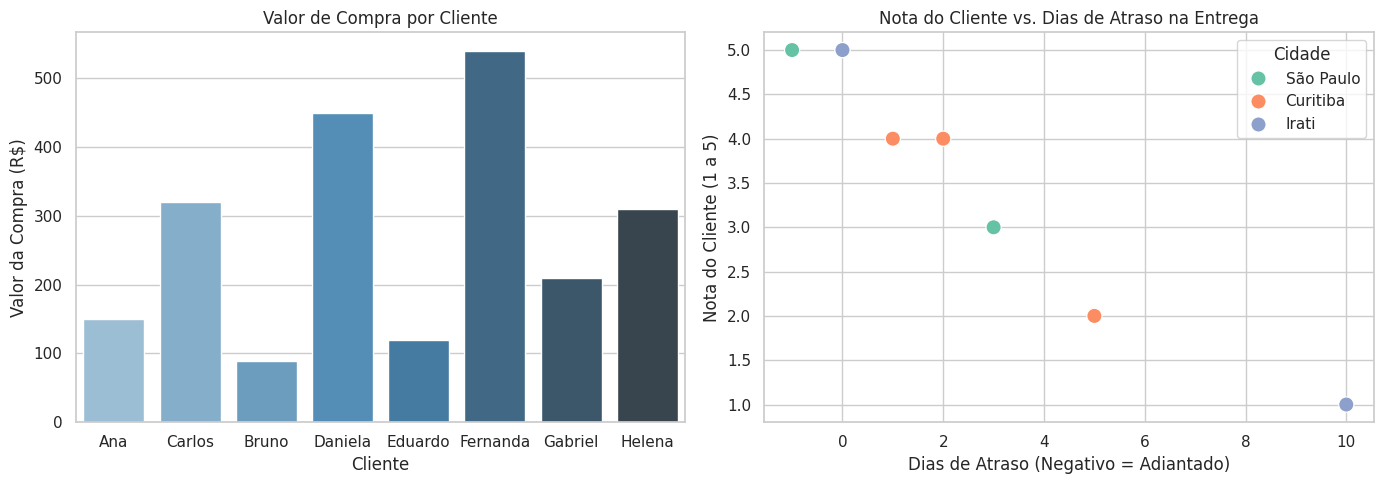


Gráficos gerados com sucesso!


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- INICIANDO ETAPA 2: VISUALIZAÇÃO DE DADOS ---")

# 1. Configurando o estilo visual dos gráficos
sns.set_theme(style="whitegrid")

# 2. Criando uma figura com dois gráficos lado a lado (Subplots)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Valor da Compra por Cliente (Gráfico de Barras)
sns.barplot(
    ax=axes[0],
    x="Cliente",
    y="Valor_Compra",
    data=df,
    palette="Blues_d"
)
axes[0].set_title("Valor de Compra por Cliente")
axes[0].set_xlabel("Cliente")
axes[0].set_ylabel("Valor da Compra (R$)")

# Gráfico 2: Relação entre Dias de Atraso e Nota do Cliente (Gráfico de Dispersão)
sns.scatterplot(
    ax=axes[1],
    x="Dias_Atraso",
    y="Nota_Cliente",
    hue="Cidade",
    data=df,
    s=120,
    palette="Set2"
)
axes[1].set_title("Nota do Cliente vs. Dias de Atraso na Entrega")
axes[1].set_xlabel("Dias de Atraso (Negativo = Adiantado)")
axes[1].set_ylabel("Nota do Cliente (1 a 5)")

# 3. Ajustando o layout para evitar sobreposições e exibindo
plt.tight_layout()
plt.show()

print("\nGráficos gerados com sucesso!")

In [4]:
import pandas as pd
from sklearn.linear_model import LinearRegression

print("--- INICIANDO ETAPA 3: INTRODUÇÃO AO MACHINE LEARNING ---")

# 1. Definindo as variáveis de entrada (Features) e a variável que queremos prever (Target)
# Features: Valor da Compra e Dias de Atraso
X = df[["Valor_Compra", "Dias_Atraso"]]

# Target: Nota que o cliente deu
y = df["Nota_Cliente"]

# 2. Instanciando e treinando o modelo de Regressão Linear
modelo = LinearRegression()
modelo.fit(X, y)

print("Modelo de Machine Learning treinado com sucesso!")

# 3. Fazendo uma previsão com novos dados simulados
# Exemplo: Um pedido de R$ 300,00 que teve 2 dias de atraso
novo_pedido = [[300.0, 2]]
nota_prevista = modelo.predict(novo_pedido)

print(f"\nSimulação de Previsão para um novo pedido (R$ 300,00 com 2 dias de atraso):")
print(f"Nota estimada do cliente: {nota_prevista[0]:.2f} (escala de 1 a 5)")

--- INICIANDO ETAPA 3: INTRODUÇÃO AO MACHINE LEARNING ---
Modelo de Machine Learning treinado com sucesso!

Simulação de Previsão para um novo pedido (R$ 300,00 com 2 dias de atraso):
Nota estimada do cliente: 3.59 (escala de 1 a 5)


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [5]:
import pandas as pd
import numpy as np

print("--- ETAPA AVANÇADA: LIMPEZA E ENGENHARIA DE DADOS ---")

# 1. Simulando um DataFrame com dados "sujos" (problemas comuns no mercado de trabalho)
dados_brutos = {
    "ID_Transacao": [501, 502, 503, 504, 505, 506],
    "Categoria": ["Eletrônicos", "Casa", "Eletrônicos", np.nan, "Moda", "Casa"],
    "Preco": [1200.0, 350.0, None, 150.0, 80.0, 420.0],
    "Qtd_Vendida": [2, 5, 1, 3, None, 4]
}

df_sujo = pd.DataFrame(dados_brutos)
print("Dados Originais (com valores nulos/faltantes):")
print(df_sujo)

# 2. Tratamento de Dados Nulos (Imputação e Limpeza)
# Preenchendo valores ausentes de preço com a média da coluna
media_preco = df_sujo["Preco"].mean()
df_sujo["Preco"] = df_sujo["Preco"].fillna(media_preco)

# Preenchendo quantidade vendida ausente com a mediana ou um valor padrão (ex: 1)
df_sujo["Qtd_Vendida"] = df_sujo["Qtd_Vendida"].fillna(1)

# Preenchendo categorias ausentes com "Desconhecido"
df_sujo["Categoria"] = df_sujo["Categoria"].fillna("Desconhecido")

# 3. Engenharia de Recursos (Feature Engineering): Criando a coluna de Faturamento Total por linha
df_sujo["Faturamento_Total"] = df_sujo["Preco"] * df_sujo["Qtd_Vendida"]

print("\n--- DADOS APÓS LIMPEZA E ENGENHARIA DE RECURSOS ---")
print(df_sujo)

# 4. Agrupamento analítico profissional
resumo_categoria = df_sujo.groupby("Categoria")["Faturamento_Total"].sum().reset_index()
print("\n--- FATURAMENTO POR CATEGORIA ---")
print(resumo_categoria)

--- ETAPA AVANÇADA: LIMPEZA E ENGENHARIA DE DADOS ---
Dados Originais (com valores nulos/faltantes):
   ID_Transacao    Categoria   Preco  Qtd_Vendida
0           501  Eletrônicos  1200.0          2.0
1           502         Casa   350.0          5.0
2           503  Eletrônicos     NaN          1.0
3           504          NaN   150.0          3.0
4           505         Moda    80.0          NaN
5           506         Casa   420.0          4.0

--- DADOS APÓS LIMPEZA E ENGENHARIA DE RECURSOS ---
   ID_Transacao     Categoria   Preco  Qtd_Vendida  Faturamento_Total
0           501   Eletrônicos  1200.0          2.0             2400.0
1           502          Casa   350.0          5.0             1750.0
2           503   Eletrônicos   440.0          1.0              440.0
3           504  Desconhecido   150.0          3.0              450.0
4           505          Moda    80.0          1.0               80.0
5           506          Casa   420.0          4.0             1680.0

--- F

In [6]:
from sklearn.tree import DecisionTreeClassifier

print("--- ETAPA: CLASSIFICAÇÃO COM MACHINE LEARNING ---")

# 1. Definindo as variáveis preditoras (Features) e o Alvo (Target)
X_ml = df_sujo[["Preco", "Qtd_Vendida"]]
y_ml = df_sujo["Categoria"]

# 2. Criando e treinando o modelo de Árvore de Decisão
modelo_classificacao = DecisionTreeClassifier(random_state=42)
modelo_classificacao.fit(X_ml, y_ml)

print("Modelo de Classificação treinado com sucesso!")

# 3. Testando o modelo com uma nova transação simulada
# Exemplo: Um produto que custa R$ 400,00 e foram vendidas 4 unidades
transacao_teste = [[400.0, 4]]
categoria_prevista = modelo_classificacao.predict(transacao_teste)

print(f"\nSimulação de Previsão para um produto (Preço: R$ 400,00 | Qtd: 4):")
print(f"Categoria estimada pelo modelo: {categoria_prevista[0]}")

--- ETAPA: CLASSIFICAÇÃO COM MACHINE LEARNING ---
Modelo de Classificação treinado com sucesso!

Simulação de Previsão para um produto (Preço: R$ 400,00 | Qtd: 4):
Categoria estimada pelo modelo: Casa


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## 🚀 Pipeline Completo: Engenharia de Dados & Machine Learning

Este projeto demonstra competências práticas em Python aplicadas a cenários reais de tecnologia:

1. **Limpeza e Tratamento de Dados (Pandas & NumPy):** Tratamento de valores nulos e remoção de inconsistências em bases transacionais.
2. **Engenharia de Atributos (Feature Engineering):** Criação de novas métricas de negócio, como o cálculo automatizado de faturamento total.
3. **Análise e Visualização (Matplotlib & Seaborn):** Geração de gráficos estatísticos para análise de comportamento de entrega e faturamento.
4. **Modelagem Preditiva (Scikit-Learn):** Implementação de Regressão Linear e Árvore de Decisão (*Decision Tree*) para previsões e classificações automáticas.